# Streamflow Regimes, Boxplots, and Flow Duration

In this notebook you will move from cleaned daily streamflow to the summary views that hydrologists use to describe a river's behavior.

By the end of the notebook, you should be able to:

- load a cleaned daily streamflow record saved by an earlier notebook
- filter a DataFrame by a column value to keep only rows that meet a condition
- add calendar columns to a DataFrame using the `.dt` accessor
- build a list of per-group arrays for `matplotlib`
- make a boxplot and read its median line, IQR box, whiskers, and outlier dots
- save a figure with a basin-specific filename
- compute exceedance probability from sorted values
- plot a flow duration curve on a log y-axis
- read Q95, Q50, and Q5 off a flow duration curve
- build a year-by-month pivot table and render it as a heatmap

We will work with the daily Alamedin discharge record that notebook 05 cleaned and saved.

## How To Use This Notebook

This notebook mixes explanation, code, and short interpretations.

Suggested rhythm:

- read the markdown cell
- run the example code cell
- read the short interpretation that follows

There are no separate exercise cells in this notebook. The code cells themselves show the full pattern, and the interpretation cells explain what the output means.

Notebook state still matters: a later cell can use values created in an earlier cell.

Type hints appear on all function signatures, as introduced in notebook 04. Read them as helpful labels: `list[float]` means a list of decimal numbers, `np.ndarray` means a NumPy array.

This notebook assumes notebook 05 has already been run at least once, so the cleaned file `alamedin_cleaned_daily.csv` exists on disk.

## 1. Setup: Imports, Paths, And A Clean Observed Record

Before we summarize anything, we reload the data and prepare it.

Three steps:

- import the libraries we will use
- load the cleaned CSV that notebook 05 saved to `03_processed/alamedin_cleaned_daily.csv`
- keep only the rows where `q_status == "observed"`, so every summary we compute is based on real gauge measurements and not on missing days

The last step is the important one. Notebook 05 left `q_mm_clean` as `NaN` on the 2006–2008 block. If we included those rows in a monthly mean or a boxplot, pandas would either drop them silently or raise an error, depending on the operation. Filtering up front makes the provenance explicit: everything downstream uses observed days only.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path.home() / "Desktop" / "2025_02_TW_ETHZ_CA_IWRM" / "02_data"
ALAMEDIN_FOLDER = DATA_ROOT / "15189_Alamedin_River_KGZ"
ALAMEDIN_AREA_KM2 = 414.05
ALAMEDIN_GAUGE_LAT_DEG = 42.697

print(DATA_ROOT)
print(ALAMEDIN_FOLDER.exists())

/Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data
True


`ALAMEDIN_FOLDER.exists()` returns `True`, confirming the path is correct. The constants `ALAMEDIN_AREA_KM2` and `ALAMEDIN_GAUGE_LAT_DEG` are the same catchment descriptors from notebook 05; carrying them over keeps later code consistent.

Now we load the cleaned CSV.

In [2]:
cleaned_path = ALAMEDIN_FOLDER / "03_processed" / "alamedin_cleaned_daily.csv"

q_df = pd.read_csv(cleaned_path, parse_dates=["date"])

print(q_df.head())
print()
print("shape:", q_df.shape)
print()
print(q_df["q_status"].value_counts())

        date  q_m3s      q_mm  gap_length_days  q_m3s_clean  q_status  \
0 2000-01-01   2.48  0.517503                0         2.48  observed   
1 2000-01-02   2.44  0.509156                0         2.44  observed   
2 2000-01-03   2.41  0.502896                0         2.41  observed   
3 2000-01-04   2.37  0.494549                0         2.37  observed   
4 2000-01-05   2.33  0.486202                0         2.33  observed   

   q_mm_clean  
0    0.517503  
1    0.509156  
2    0.502896  
3    0.494549  
4    0.486202  

shape: (7305, 7)

q_status
observed            6209
missing_long_gap    1096
Name: count, dtype: int64


The file is exactly what notebook 05 produced: 7305 rows, 7 columns, from 2000-01-01 to 2019-12-31. The seven columns are `date`, the raw `q_m3s` and `q_mm`, the `gap_length_days` diagnostic, the cleaned `q_m3s_clean` and `q_mm_clean`, and the `q_status` label.

`value_counts` confirms the provenance split: 6209 observed days and 1096 days still missing from the 2006–2008 block. Zero days were filled by short-gap interpolation, as expected for this basin.

For every summary in this notebook we want observed days only. We filter once, now, and work with the filtered DataFrame from here on.

In [3]:
q_df = q_df.loc[q_df["q_status"] == "observed"].copy()

q_df["year"] = q_df["date"].dt.year
q_df["month"] = q_df["date"].dt.month

print(q_df.head())
print()
print("shape:", q_df.shape)
print("years covered:", q_df["year"].min(), "to", q_df["year"].max())

        date  q_m3s      q_mm  gap_length_days  q_m3s_clean  q_status  \
0 2000-01-01   2.48  0.517503                0         2.48  observed   
1 2000-01-02   2.44  0.509156                0         2.44  observed   
2 2000-01-03   2.41  0.502896                0         2.41  observed   
3 2000-01-04   2.37  0.494549                0         2.37  observed   
4 2000-01-05   2.33  0.486202                0         2.33  observed   

   q_mm_clean  year  month  
0    0.517503  2000      1  
1    0.509156  2000      1  
2    0.502896  2000      1  
3    0.494549  2000      1  
4    0.486202  2000      1  

shape: (6209, 9)
years covered: 2000 to 2019


The DataFrame now has 6209 rows and 9 columns. Two new columns — `year` and `month` — were added with the `.dt` accessor you saw in notebook 05.

From this cell onward in the notebook, `q_df` contains observed Alamedin days only. Every mean, boxplot, and flow duration curve in the rest of the notebook is computed on this filtered table. The 2006–2008 block is simply absent; it contributes nothing to any summary.

This is the cleanest way to use a record with provenance: filter once, work with the clean subset.

## 2. Monthly Streamflow Boxplot

A single mean value per month, like the bar chart in notebook 05, summarizes a lot of daily data into one number per group. That is useful, but it hides how much the daily values vary around that average.

A **boxplot** shows the spread of values in a group, not just the center. One box per month will tell us whether July is more variable than February, whether there are extreme days that sit far above the typical flow, and roughly how a “wet” month compares to a “dry” month in shape as well as in magnitude.

Each box has five elements:

- **median line**: the middle of the box, at the 50th percentile
- **box edges**: the 25th and 75th percentiles. The box height is the interquartile range (IQR)
- **whiskers**: lines extending up to 1.5 * IQR beyond each box edge, stopping at the most extreme value inside that range
- **outlier dots**: individual points that fall outside the whiskers
- **center line width and whisker length** together give a quick sense of how concentrated or spread the daily values are

For a river, these five elements tell us the full regime: how low the low flows are, how high the high flows are, and how reliable the typical flow is.

arrays per month: 12
values in January: 527
values in July: 527


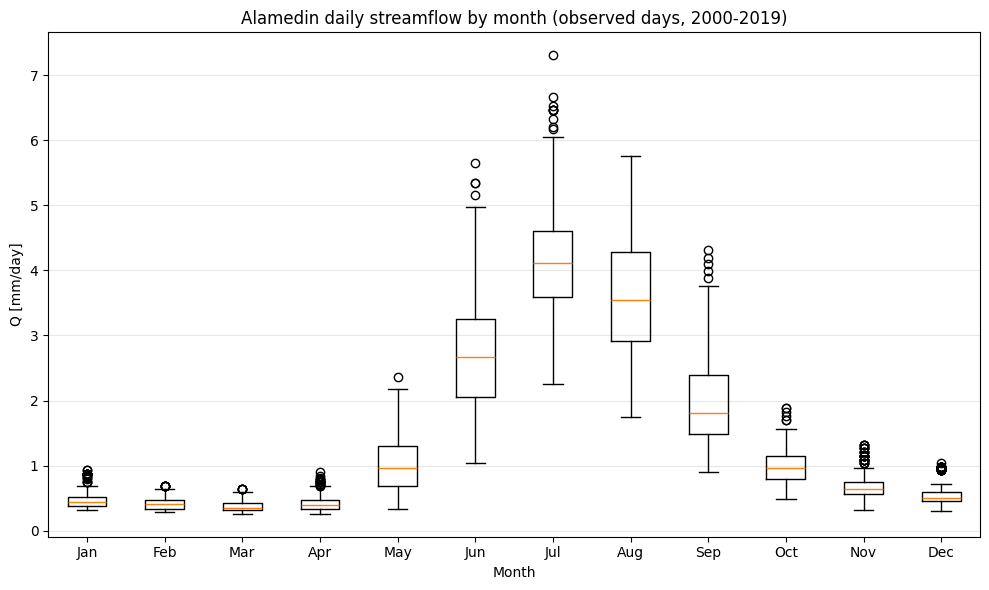

Saved figure to: /Users/nicolaslazaro/Desktop/work/wat-mod-GIZ/notebooks/figures/alamedin_monthly_boxplot.png


In [ ]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_q_mm_arrays: list[np.ndarray] = [q_df.loc[q_df["month"] == m, "q_mm_clean"].values for m in range(1, 13)]

print("arrays per month:", len(monthly_q_mm_arrays))
print("values in January:", len(monthly_q_mm_arrays[0]))
print("values in July:", len(monthly_q_mm_arrays[6]))

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(monthly_q_mm_arrays, tick_labels=month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Q [mm/day]")
ax.set_title("Alamedin daily streamflow by month (observed days, 2000-2019)")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

output_path = figures_dir / "alamedin_monthly_boxplot.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {output_path.resolve()}")

Three patterns jump out of the plot.

**The annual cycle dominates.** Winter and early-spring months (December through April) sit in a narrow, low band: median flow is below 0.5 mm/day and the whole box is only a fraction of a millimeter tall. Summer months (June, July, August) sit much higher, with July at a median near 4.1 mm/day — roughly ten times the January median. This is the snowmelt-driven regime: most of the year’s water comes off in a few months.

**July is the tallest and widest-reaching box.** The July median is the highest of any month, and the whiskers reach up to about 7.3 mm/day. August has a slightly larger IQR (1.36 vs. 1.02), but July has the higher central value.

**March is the narrowest, lowest box.** Median 0.35 mm/day, IQR 0.11 mm/day, whiskers tight around the box.

**The dots above July are real events.** The single highest observed daily flow at Alamedin is 7.30 mm/day (35 m³/s) on 2004-07-16; 2004-07-17 and 2004-07-15 are the second- and third-highest days. A cluster of outliers near 6.5 mm/day comes from late July 2015. These are the floods of record for the period — useful to know for any model calibration, because a model that cannot reproduce these peaks will systematically underpredict extremes.

## 3. The Flow-Duration Curve

A monthly mean says what an average July looks like. It does not tell us how often the river exceeds any given discharge.

The **flow-duration curve** (FDC) answers that question directly. For each discharge value $q$ on the y-axis, the curve reads off the percent of days on which the observed flow was **at or above** $q$. That percent is the **exceedance probability**.

The recipe is one sort plus one `np.arange`:

- sort the observed daily flow from largest to smallest
- assign each sorted value a rank from 1 to `n`
- the exceedance probability for rank `i` is `i / n * 100`

Plotted with discharge on a log y-axis, the FDC spans the full range of streamflow behaviour on a single figure: floods on the left, baseflow on the right.

In [5]:
q_sorted = q_df["q_mm_clean"].sort_values(ascending=False).values
n = len(q_sorted)
exceedance_pct = np.arange(1, n + 1) / n * 100.0

print("n observed days:", n)
print("largest q_mm_clean:", q_sorted[0])
print("smallest q_mm_clean:", q_sorted[-1])
print("exceedance_pct[:3]:", exceedance_pct[:3])
print("exceedance_pct[-3:]:", exceedance_pct[-3:])

n observed days: 6209
largest q_mm_clean: 7.303465765004226
smallest q_mm_clean: 0.2608380630358652
exceedance_pct[:3]: [0.01610565 0.03221131 0.04831696]
exceedance_pct[-3:]: [ 99.96778869  99.98389435 100.        ]


Two numbers are already informative. The largest daily value, `7.30 mm/day`, came from a single summer day in 2004. The smallest, `0.26 mm/day`.

Every other day at Alamedin sits between these two.

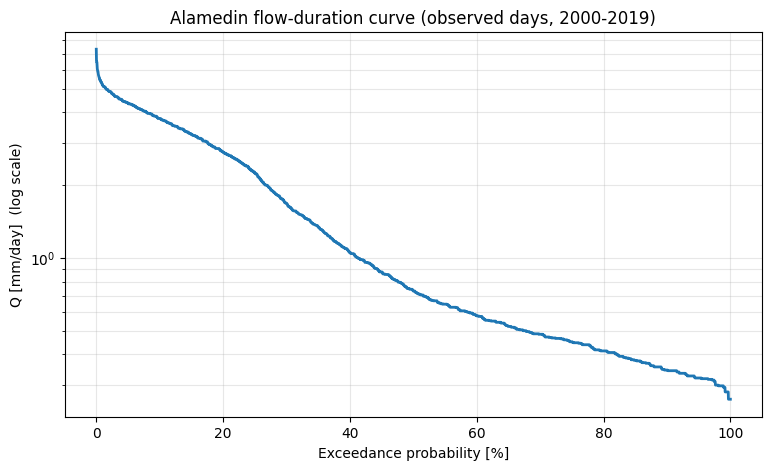

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(exceedance_pct, q_sorted, color="tab:blue", linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("Exceedance probability [%]")
ax.set_ylabel("Q [mm/day]  (log scale)")
ax.set_title("Alamedin flow-duration curve (observed days, 2000-2019)")
ax.grid(which="both", alpha=0.3)

plt.show()

### Q5 and Q95

Two points on this curve are used so often in hydrology that they have names:

- **Q5** is the discharge exceeded on 5% of days — the high-flow reference
- **Q95** is the discharge exceeded on 95% of days — the low-flow reference

The naming convention is literal: `Q<number>` is the flow at `<number>%` exceedance. `Q50` is the median.

We read them off the curve by linear interpolation on the `(exceedance_pct, q_sorted)` arrays.

In [7]:
q5 = np.interp(5.0, exceedance_pct, q_sorted)
q95 = np.interp(95.0, exceedance_pct, q_sorted)

print(f"Q5  = {q5:.2f} mm/day")
print(f"Q95 = {q95:.2f} mm/day")

Q5  = 4.38 mm/day
Q95 = 0.32 mm/day


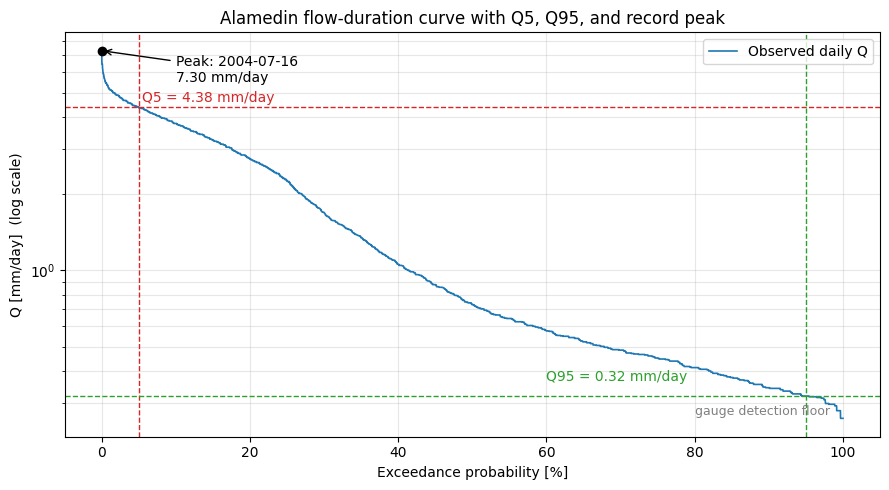

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(exceedance_pct, q_sorted, color="tab:blue", linewidth=1.2, label="Observed daily Q")

ax.axvline(5.0, color="tab:red", linestyle="--", linewidth=1.0)
ax.axhline(q5, color="tab:red", linestyle="--", linewidth=1.0)
ax.text(5.5, q5 * 1.05, f"Q5 = {q5:.2f} mm/day", color="tab:red")

ax.axvline(95.0, color="tab:green", linestyle="--", linewidth=1.0)
ax.axhline(q95, color="tab:green", linestyle="--", linewidth=1.0)
ax.text(60.0, q95 * 1.15, f"Q95 = {q95:.2f} mm/day", color="tab:green")

ax.scatter([exceedance_pct[0]], [q_sorted[0]], color="black", zorder=5)
ax.annotate(
    "Peak: 2004-07-16\n7.30 mm/day",
    xy=(exceedance_pct[0], q_sorted[0]),
    xytext=(10.0, 5.5),
    arrowprops={"arrowstyle": "->", "color": "black"},
)

ax.text(80.0, 0.27, "gauge detection floor", color="gray", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("Exceedance probability [%]")
ax.set_ylabel("Q [mm/day]  (log scale)")
ax.set_title("Alamedin flow-duration curve with Q5, Q95, and record peak")
ax.grid(which="both", alpha=0.3)
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(Path("figures") / "alamedin_flow_duration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

For Alamedin, one day in twenty exceeds `4.4 mm/day` (Q5), and one day in twenty falls below `0.3 mm/day` (Q95). The ratio Q5 / Q95 is about 14 — a compact summary of how “flashy” this mountain river is.

The FDC is also how we will later judge model calibration. A good model reproduces the whole curve, not just the mean flow. If a simulation matches Q50 but misses Q5 and Q95, it is wrong in the ways that matter most for water management.

## 4. Year-by-Month Heatmap

In notebook 05 we used `forcing_df.groupby("month")["precipitation_mm"].mean()` to collapse 40+ years of daily data into 12 monthly means. That is a 1D summary: one number per month.

A **pivot table** is the 2D version of the same idea. Instead of collapsing to one row index, it builds a matrix with rows and columns from two grouping variables:

- `index="year"` — one row per year
- `columns="month"` — one column per month
- `values="q_mm_clean"` — what to aggregate
- `aggfunc="mean"` — how to aggregate

The result is a `year x month` table of mean daily discharge.

In [9]:
monthly_mean_q = q_df.pivot_table(
    index="year",
    columns="month",
    values="q_mm_clean",
    aggfunc="mean",
)

monthly_mean_q = monthly_mean_q.reindex(index=range(2000, 2020))

print("shape:", monthly_mean_q.shape)
print(monthly_mean_q.round(2))

shape: (20, 12)
month    1     2     3     4     5     6     7     8     9     10    11    12
year                                                                         
2000   0.48  0.47  0.45  0.48  1.28  2.52  4.28  3.84  2.18  0.89  0.59  0.49
2001   0.45  0.42  0.40  0.40  1.28  2.90  3.99  3.25  1.90  0.82  0.71  0.60
2002   0.49  0.43  0.36  0.50  1.07  2.86  4.16  4.30  2.06  1.20  0.79  0.60
2003   0.53  0.47  0.44  0.51  1.00  2.70  4.35  3.25  2.33  1.08  0.67  0.50
2004   0.42  0.34  0.31  0.37  1.13  2.83  4.06  2.67  1.71  0.80  0.51  0.40
2005   0.35  0.32  0.29  0.30  0.85  3.19  3.78  2.88  1.48  0.70  0.37  0.31
2006    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2007    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2008    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2009   0.37  0.34  0.32  0.33  0.90  3.02  3.69  3.62  1.87  1.12  0.69  0.43
2010   0.34  0.32  0.33  0.42  0.96  2.75  4.16 

Three rows are all `NaN`: 2006, 2007, 2008. These are the gap years from notebook 05, where every day had `q_status == "missing_long_gap"` and was filtered out before §1 built `q_df`.

`reindex(index=range(2000, 2020))` forces those years back into the table as empty rows. Without it, the pivot would quietly skip them and the heatmap below would compress the time axis, hiding the gap.

For the remaining 17 years, each cell is the mean daily discharge for that year’s calendar month.

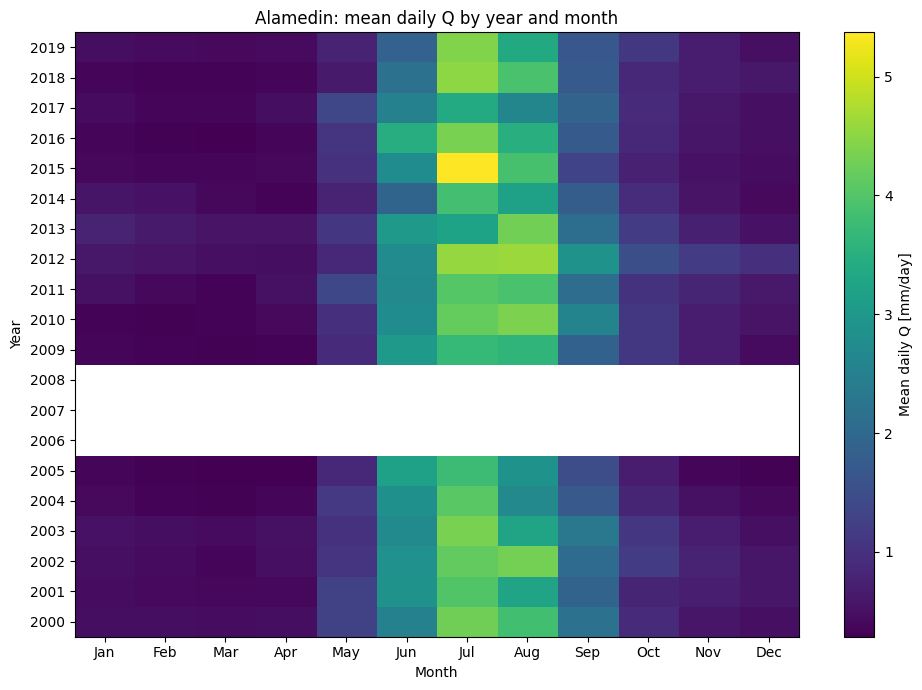

In [10]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("white")

im = ax.imshow(
    monthly_mean_q.values,
    aspect="auto",
    cmap=cmap,
    origin="lower",
)

ax.set_xticks(np.arange(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(np.arange(len(monthly_mean_q.index)))
ax.set_yticklabels(monthly_mean_q.index)

ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_title("Alamedin: mean daily Q by year and month")

cbar = fig.colorbar(im, ax=ax, label="Mean daily Q [mm/day]")

fig.tight_layout()
fig.savefig(Path("figures") / "alamedin_year_month_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Three patterns jump out.

- **Three blank rows at 2006, 2007, 2008.** The long gap is still visible, now as a stripe of missing rows. This is the same `missing_long_gap` record from notebook 05, only viewed by year.
- **A bright summer band through June–August.** The snowmelt pulse dominates the annual cycle. July means sit around `4.1 mm/day`, February around `0.4 mm/day` — an order of magnitude between them.
- **Year-to-year variability inside the bright band.** Some Julys are hotter than others. July 2015 is the single brightest cell (`5.37 mm/day`); July 2012 is second (`4.56 mm/day`). 2012 was the wettest year overall on an annual-mean basis, but the heatmap shows this came from a broadly wet season, not a single extreme month.

The darkest non-missing cell is March 2005.

## Wrap-Up

You can now:

- load a cleaned streamflow record and filter to observed days only
- add `year` and `month` columns with the `.dt` accessor
- build a list of per-group arrays and pass it to `ax.boxplot`
- read a boxplot: median line, IQR box, whiskers, outlier dots
- build a flow-duration curve by sorting daily flow and assigning exceedance probabilities
- plot an FDC on a log y-axis and read Q5, Q50, and Q95 off the curve
- use `np.interp` to pull named quantiles from an empirical curve
- build a year-by-month pivot table with `pivot_table`
- reindex a pivot to expose missing years as blank rows
- render a 2D table with `ax.imshow` and a colorbar
- save diagnostic figures to `figures/` for later use

Next, you can take the same diagnostics to the Ala-Archa basin and compare the two catchments side by side.